# Yield Prediction Training (Phase 4)

Train RF, XGBoost (Optuna), LSTM, and Ensemble models.
Compare with/without disease severity feature.

In [1]:
import os
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

if Path.cwd().name == 'notebooks':
    os.chdir('..')

from src.models.yield_model import (
    build_yield_dataset, prepare_Xy, build_lstm_sequences,
    train_rf_baseline, optuna_xgboost, train_lstm,
    ensemble_predict, optuna_ensemble_weights, evaluate_metrics
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## 1. Build Feature Dataset

In [2]:
DAILY_CSV = 'data/raw/climate_daily_2015_2024.csv'
YIELD_CSV = 'data/raw/nhb_yield_mock_2015_2024.csv'

df = build_yield_dataset(DAILY_CSV, YIELD_CSV)
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.head())

Dataset shape: (60, 15)
Columns: ['year', 'region', 'variety', 'yield_t_ha', 'rain_mean_30d', 'rain_cumul', 'tmax_mean', 'tmin_mean', 'temp_delta_mean', 'temp_var_30d', 'humidity_mean', 'vpd_mean', 'disease_severity', 'var_Banganapalli', 'var_Raspuri']
   year      region       variety  yield_t_ha  rain_mean_30d  rain_cumul  \
0  2015      Hassan       Raspuri        7.26       0.265000     1238.37   
1  2015      Hassan  Banganapalli        9.30       0.265000     1238.37   
2  2015       Kolar       Raspuri        6.79       0.244667      815.13   
3  2015       Kolar  Banganapalli        9.29       0.244667      815.13   
4  2015  Ramanagara       Raspuri        7.02       0.423000      836.15   

   tmax_mean  tmin_mean  temp_delta_mean  temp_var_30d  humidity_mean  \
0  29.119370  18.655425        10.463945      1.125371      73.451699   
1  29.119370  18.655425        10.463945      1.125371      73.451699   
2  30.579315  18.669589        11.909726      1.995089      69.171342  

In [3]:
X, y, feature_cols = prepare_Xy(df)
print(f"\nFeatures ({len(feature_cols)}): {feature_cols}")
print(f"X shape: {X.shape}, y shape: {y.shape}")


Features (11): ['rain_mean_30d', 'rain_cumul', 'tmax_mean', 'tmin_mean', 'temp_delta_mean', 'temp_var_30d', 'humidity_mean', 'vpd_mean', 'disease_severity', 'var_Banganapalli', 'var_Raspuri']
X shape: (60, 11), y shape: (60,)


## 2. Train/Test Split

In [4]:
# Time-based split: 2015-2021 train, 2022-2024 test (prevent future leak)
train_mask = df['year'] <= 2021
test_mask = df['year'] > 2021

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# Further split train into train/val for Optuna
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_tr.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (33, 11), Val: (9, 11), Test: (18, 11)


## 3. Random Forest Baseline

In [5]:
rf_model, rf_metrics = train_rf_baseline(X_tr_s, y_tr, X_test_s, y_test)
print("RF Baseline:", rf_metrics)

RF Baseline: {'MAE': 0.5901402554247114, 'RMSE': 0.7708827972483809, 'R2': 0.41635424586233527, 'NMAE%': 8.092120170593262}


## 4. XGBoost + Optuna

In [6]:
xgb_model, xgb_best_params = optuna_xgboost(X_tr_s, y_tr, X_val_s, y_val, n_trials=100)
xgb_preds = xgb_model.predict(X_test_s)
xgb_metrics = evaluate_metrics(y_test, xgb_preds)
print("XGBoost:", xgb_metrics)
print("Best params:", xgb_best_params)

XGBoost: {'MAE': 0.5060492157936096, 'RMSE': 0.6744263798936386, 'R2': 0.5532734990119934, 'NMAE%': 6.939046859741211}
Best params: {'max_depth': 3, 'learning_rate': 0.05361018072205364, 'n_estimators': 377, 'subsample': 0.6091552065939029, 'colsample_bytree': 0.7161729107191066, 'reg_alpha': 0.0002620069780451788, 'reg_lambda': 9.57352133241457}


## 5. LSTM

In [7]:
sequences, seq_targets = build_lstm_sequences(DAILY_CSV, YIELD_CSV, seq_len=30)

seq_train = sequences[train_mask]
seq_test = sequences[test_mask]
y_seq_train = seq_targets[train_mask]
y_seq_test = seq_targets[test_mask]

# Split train for val
idx = int(len(seq_train) * 0.8)
seq_tr, seq_val = seq_train[:idx], seq_train[idx:]
y_seq_tr, y_seq_val = y_seq_train[:idx], y_seq_train[idx:]

lstm_model = train_lstm(seq_tr, y_seq_tr, seq_val, y_seq_val, epochs=200)

lstm_model.eval()
with torch.no_grad():
    lstm_preds = lstm_model(torch.tensor(seq_test)).numpy()
lstm_metrics = evaluate_metrics(y_seq_test, lstm_preds)
print("LSTM:", lstm_metrics)

LSTM: {'MAE': 0.8004978895187378, 'RMSE': 1.0141406436194604, 'R2': -0.010110855102539062, 'NMAE%': 10.976585388183594}


## 6. Ensemble (XGBoost + LSTM)

In [8]:
w_xgb = optuna_ensemble_weights(xgb_preds, lstm_preds, y_test, n_trials=50)
ensemble_preds = ensemble_predict(xgb_preds, lstm_preds, w_xgb)
ensemble_metrics = evaluate_metrics(y_test, ensemble_preds)
print(f"Ensemble (w_xgb={w_xgb:.2f}):", ensemble_metrics)

Ensemble (w_xgb=0.92): {'MAE': 0.49719879031181335, 'RMSE': 0.6780715015948544, 'R2': 0.5484315156936646, 'NMAE%': 6.81768798828125}


## 7. Comparison Table

                        MAE      RMSE        R2      NMAE%
RF Baseline        0.590140  0.770883  0.416354   8.092120
XGBoost (Optuna)   0.506049  0.674426  0.553273   6.939047
LSTM               0.800498  1.014141 -0.010111  10.976585
Ensemble (w=0.92)  0.497199  0.678072  0.548432   6.817688


Saved to reports/figures/yield_comparison.png


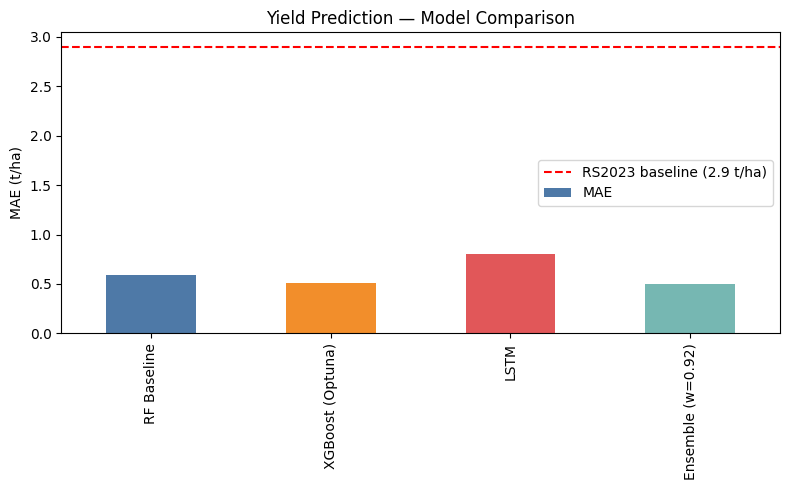

In [9]:
results = {
    'RF Baseline': rf_metrics,
    'XGBoost (Optuna)': xgb_metrics,
    'LSTM': lstm_metrics,
    f'Ensemble (w={w_xgb:.2f})': ensemble_metrics,
}

results_df = pd.DataFrame(results).T
print(results_df.to_string())

# Save
results_df.to_csv('models/yield_results.csv')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
results_df['MAE'].plot(kind='bar', ax=ax, color=['#4E79A7', '#F28E2B', '#E15759', '#76B7B2'])
ax.set_ylabel('MAE (t/ha)')
ax.set_title('Yield Prediction — Model Comparison')
ax.axhline(y=2.9, color='red', linestyle='--', label='RS2023 baseline (2.9 t/ha)')
ax.legend()
plt.tight_layout()
plt.savefig('reports/figures/yield_comparison.png')
print("Saved to reports/figures/yield_comparison.png")